In [1]:
# making environment
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
# data input
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# null values in the dataset
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Since the cabin column has 687 null values from the 891 and ,the passengerId , Name and ticket are not related the servival.**

In [8]:

df = df.drop(columns=['Cabin','PassengerId','Name','Ticket'])


In [9]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [10]:
# checking the unique variable in the colomns
print(df['Sex'].unique())
print(df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


In [11]:

le = OneHotEncoder(drop='first', sparse_output=False)
encoded_vars = le.fit_transform(df[['Sex', 'Embarked']])
encoded_df = pd.DataFrame(encoded_vars, columns=le.get_feature_names_out(['Sex', 'Embarked']))
df = pd.concat([df.drop(columns=['Sex', 'Embarked']), encoded_df], axis=1)

**Since there is only 2 diff type of variable so i use labelEncoder male as 1 and femail as 2**

In [12]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Embarked_nan
0,0,3,22.0,1,0,7.2500,1.0,0.0,1.0,0.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,0.0,1.0,0.0
3,1,1,35.0,1,0,53.1000,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,1.0,0.0,1.0,0.0


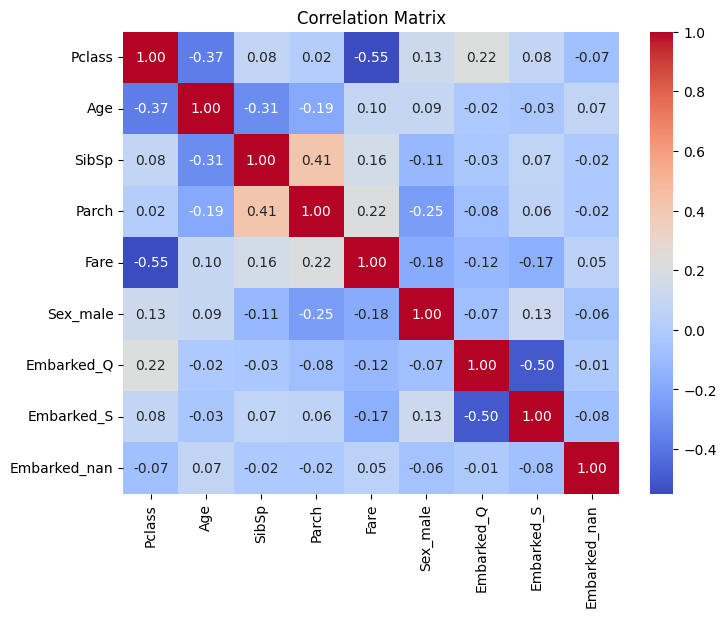

In [13]:
# heatmap for the correlation

plt.figure(figsize=(8,6))

sns.heatmap(

    df.iloc[:, 1:].corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'

)

plt.title("Correlation Matrix")

plt.show()

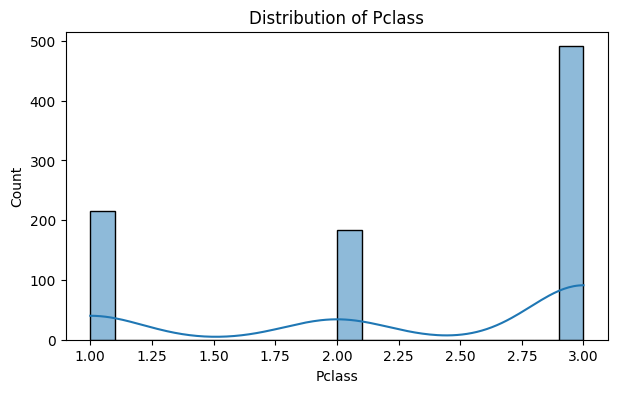

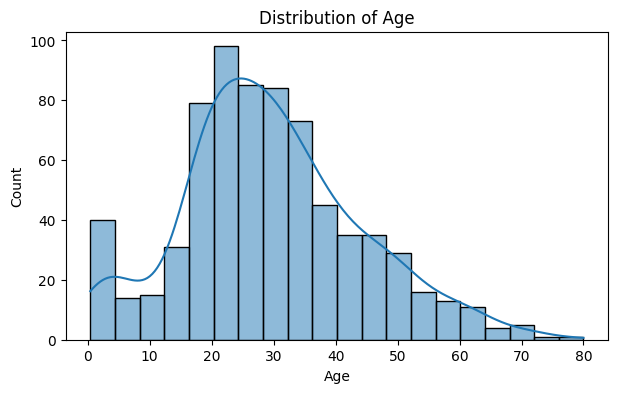

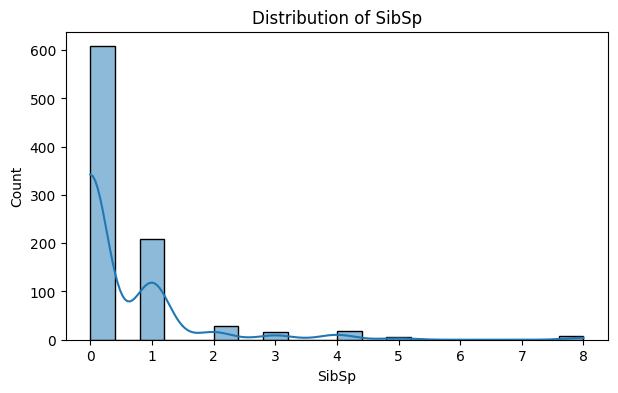

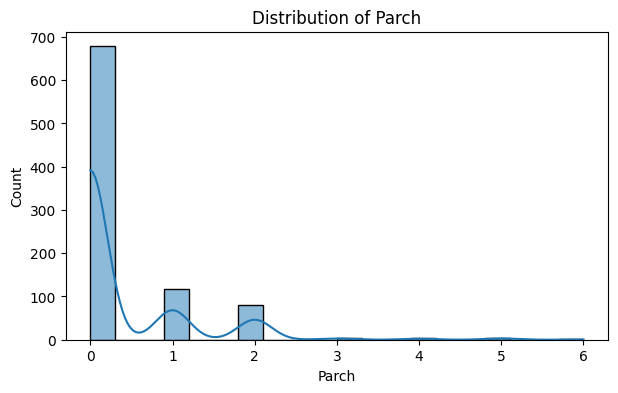

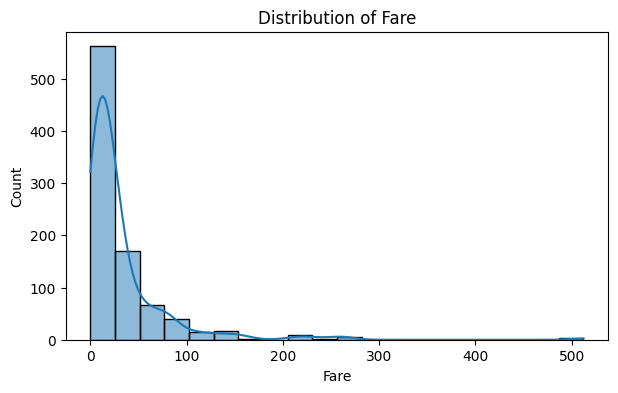

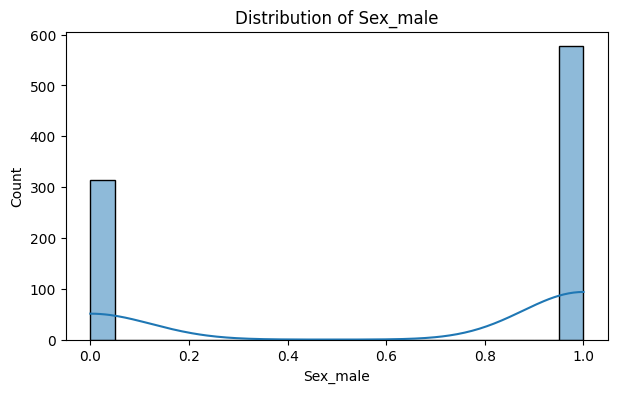

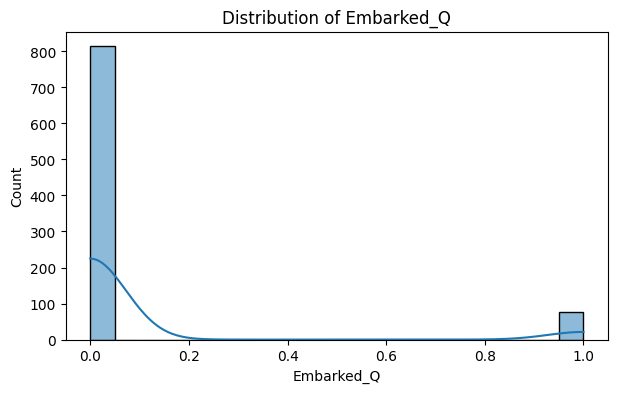

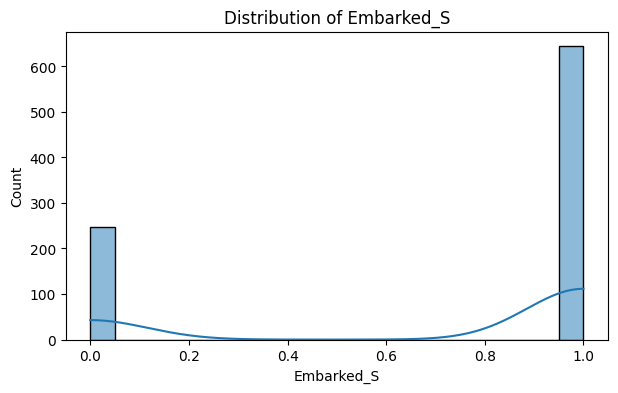

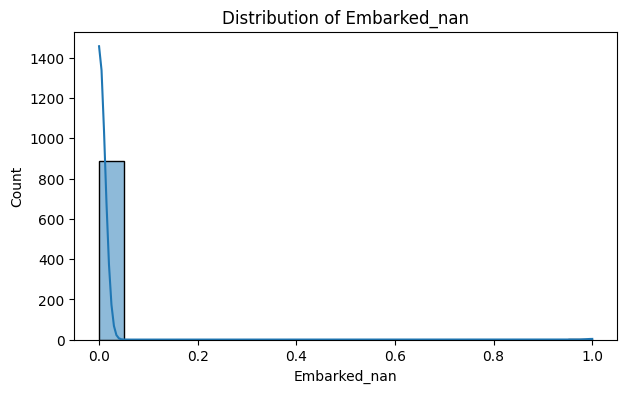

In [14]:
# inclination of data

numerical_cols = df.columns[1:]

for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[col],

        kde=True,

        bins=20

    )

    plt.title(f"Distribution of {col}")

    plt.show()

In [15]:
df.isnull().sum()

Survived          0
Pclass            0
Age             177
SibSp             0
Parch             0
Fare              0
Sex_male          0
Embarked_Q        0
Embarked_S        0
Embarked_nan      0
dtype: int64

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [17]:
df.isnull().sum()

Survived        0
Pclass          0
Age             0
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
Embarked_nan    0
dtype: int64

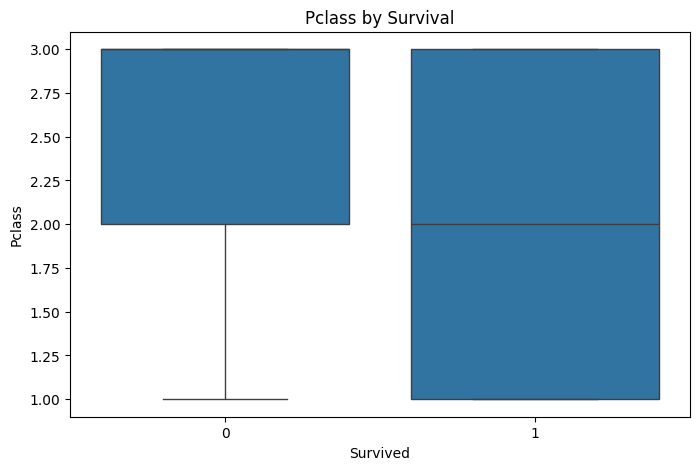

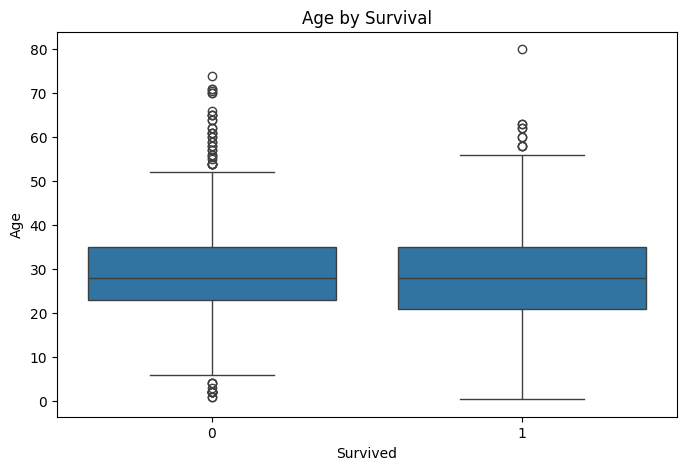

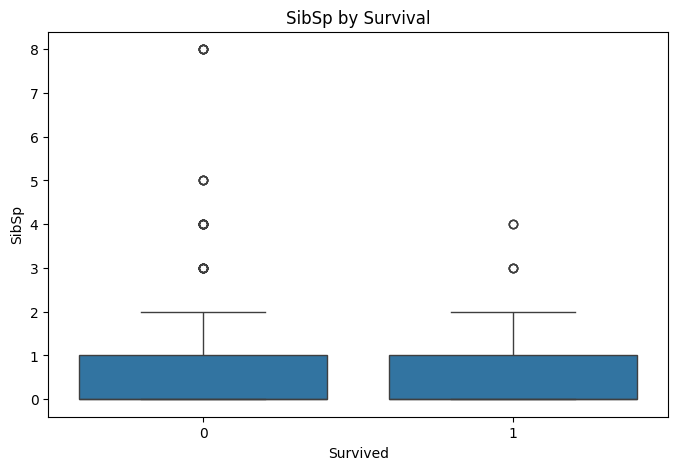

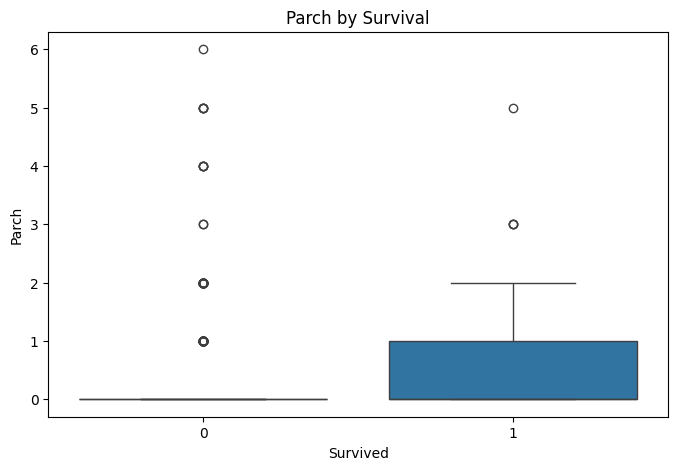

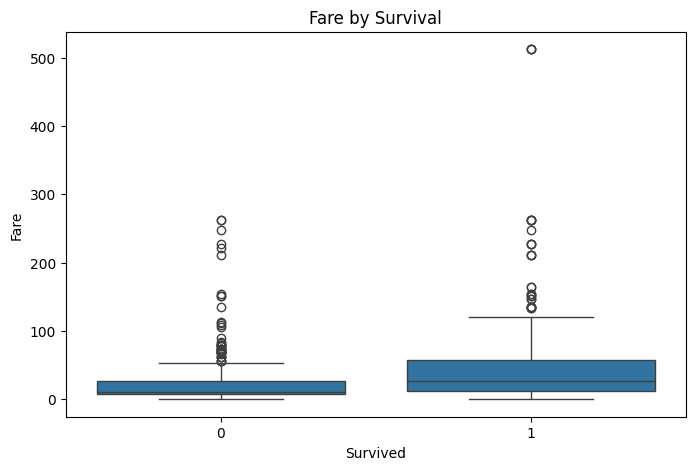

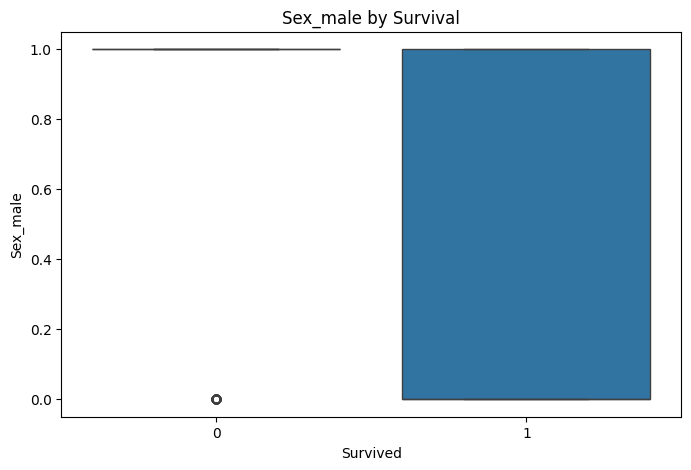

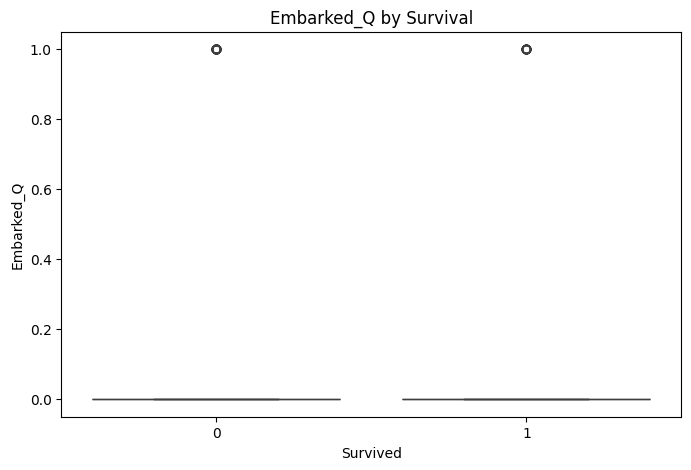

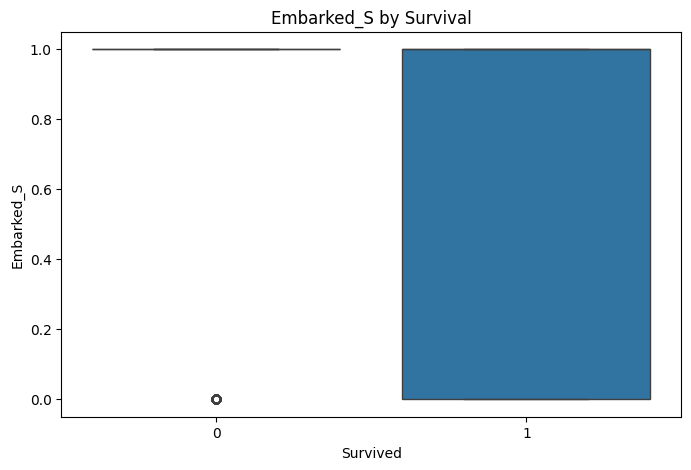

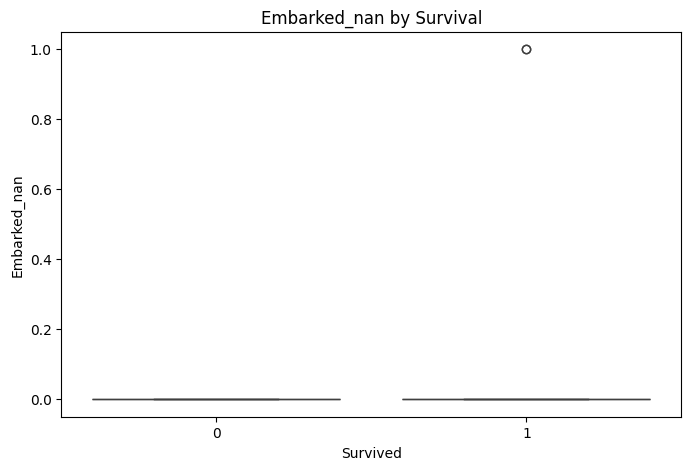

In [18]:
# 
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(

        x='Survived',

        y=col,

        data=df

    )

    plt.title(f"{col} by Survival")

    plt.show()

In [21]:
# Copy dataframe to preserve original data
df_clean = df.copy()
numeric_cols =df.columns[1:]
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only rows within bounds for this specific column
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

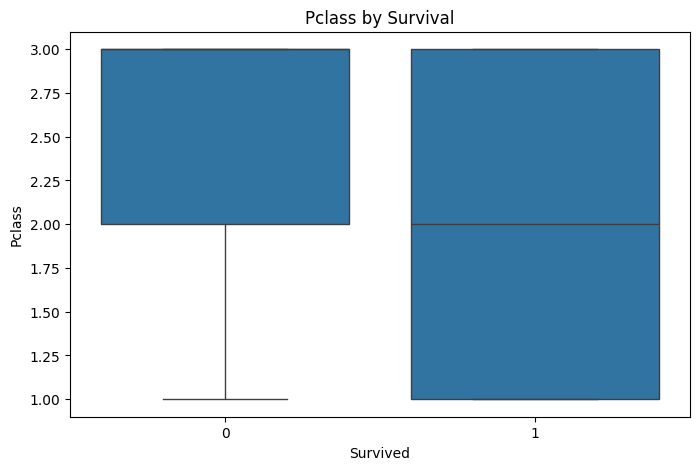

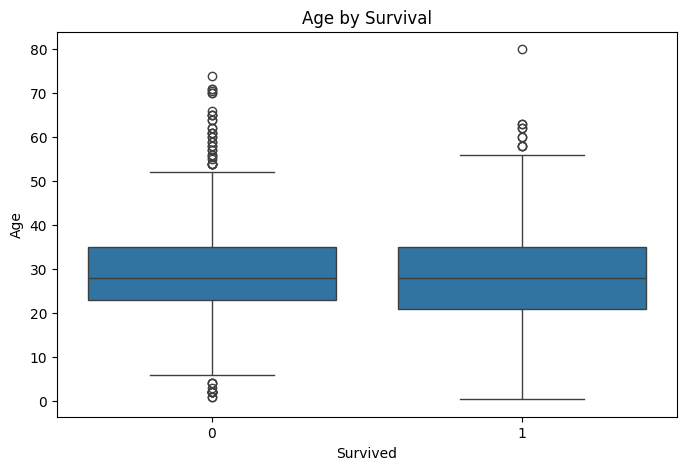

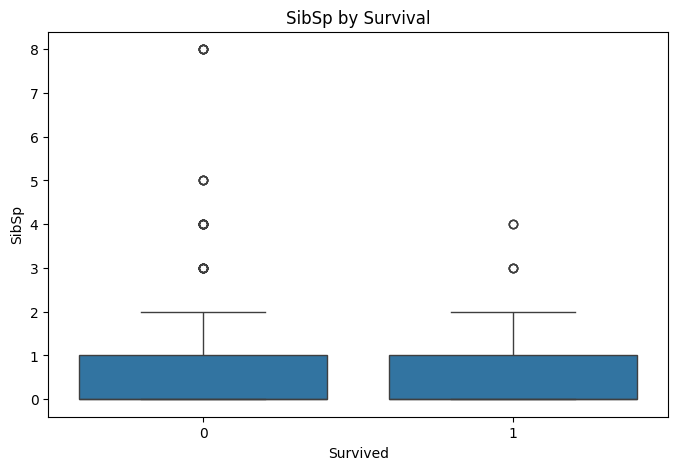

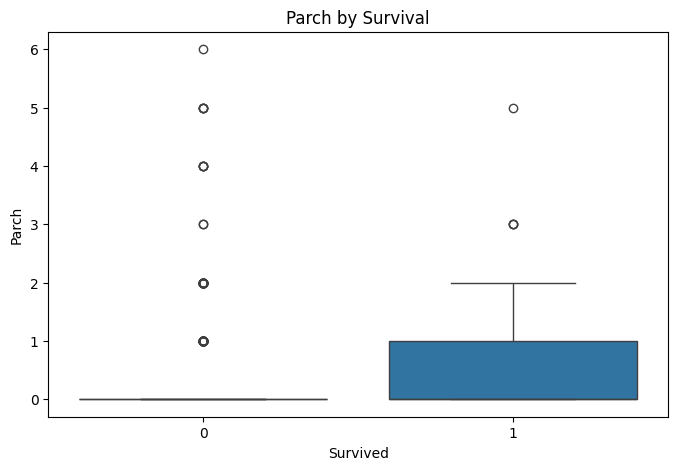

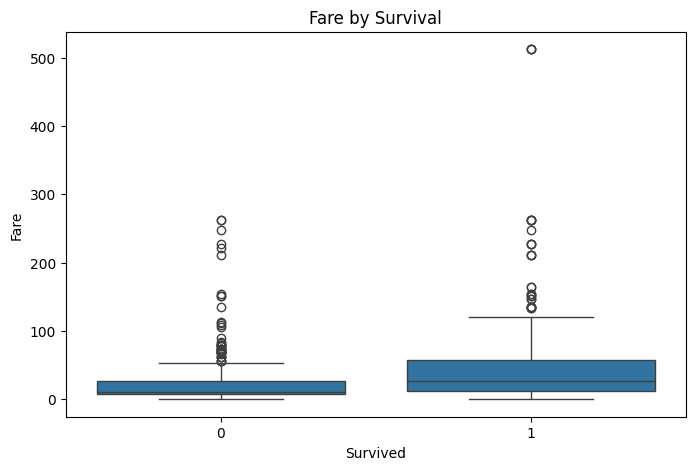

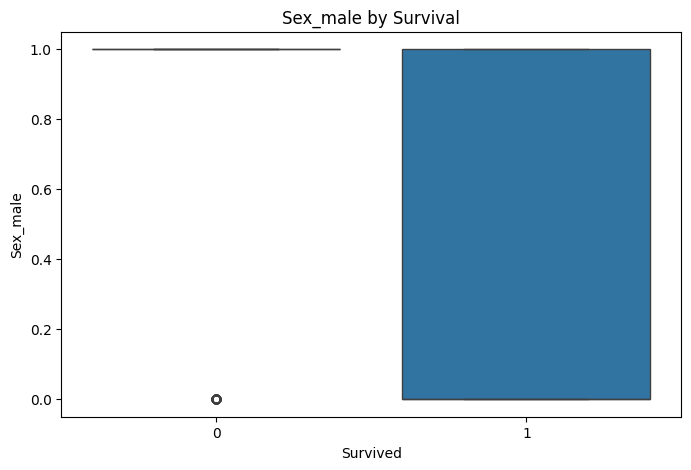

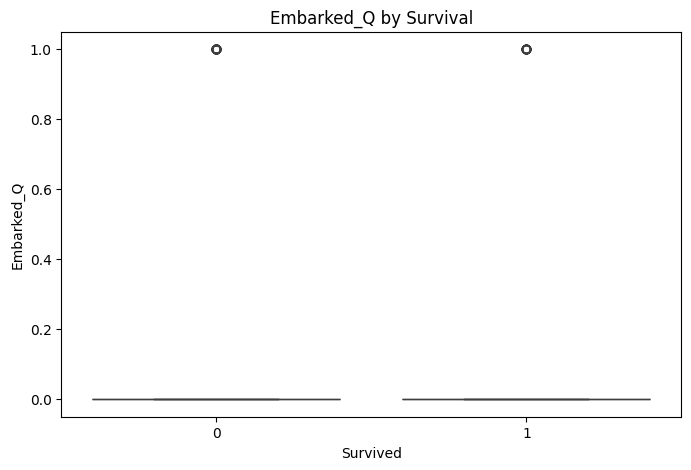

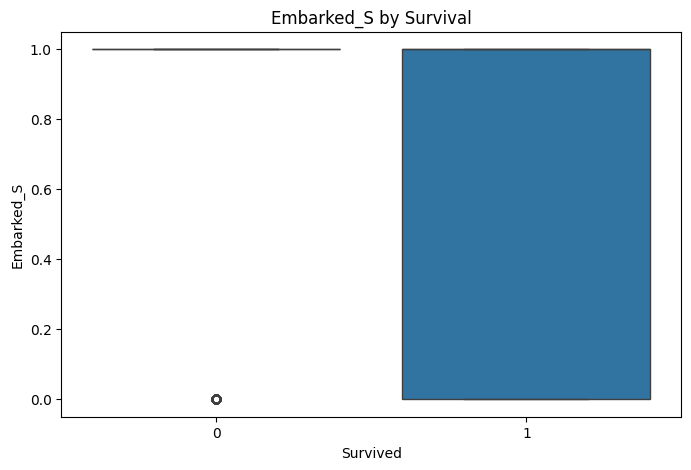

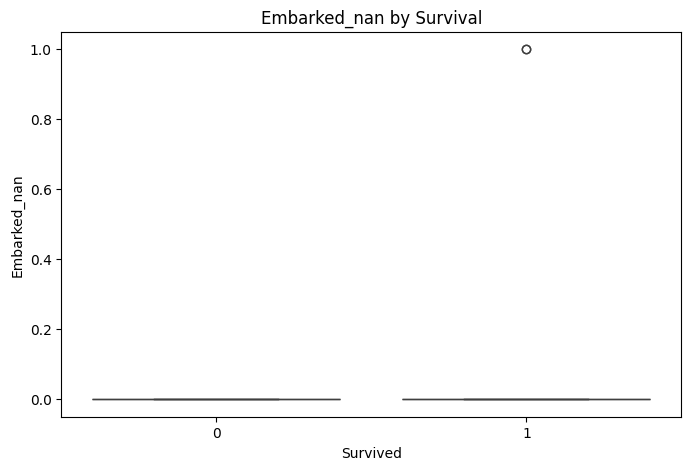

In [22]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(

        x='Survived',

        y=col,

        data=df

    )

    plt.title(f"{col} by Survival")

    plt.show()